Pada dataset Medical Cost Personal Dataset, variabel yang digunakan sebagai fitur adalah age, sex, bmi, children, smoker, dan region. Variabel-variabel tersebut digunakan untuk membantu memprediksi biaya medis seseorang. Sedangkan variabel target yang akan diprediksi adalah charges, yaitu biaya medis personal yang dikeluarkan oleh seseorang.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [37]:
data = pd.read_csv("insurance.csv")

data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [38]:
data.shape

(1338, 7)

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [42]:
X = data.drop("charges", axis=1)
y = data["charges"]
X.head()


,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [43]:
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


# **encoding data dan feature scaling pada numerik **

In [44]:
categorical_features = ["sex", "smoker", "region"]
numerical_features = ["age", "bmi", "children"]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (1070, 6)
Data testing : (268, 6)


# Multiple Linear regression

In [46]:
linear_model = LinearRegression()
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

linear_model.fit(X_train_processed, y_train)
y_pred_linear = linear_model.predict(X_test_processed)

# Evaluasi Linear Regression

In [47]:
r2_linear = r2_score(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)

print("Linear Regression")
print("R-squared :", r2_linear)
print("MSE       :", mse_linear)
print("MAE       :", mae_linear)

Linear Regression
R-squared : 0.7835929767120722
MSE       : 33596915.851361476
MAE       : 4181.194473753652


# Visualisasi

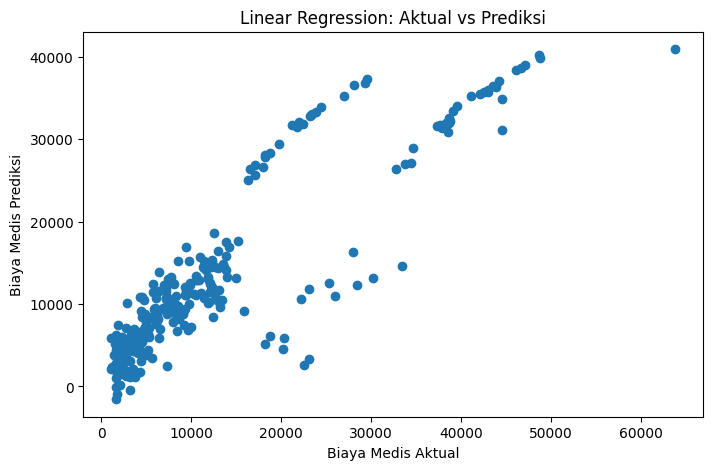

In [48]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_linear)

plt.xlabel("Biaya Medis Aktual")
plt.ylabel("Biaya Medis Prediksi")
plt.title("Linear Regression: Aktual vs Prediksi")

plt.show()

# Evaluasi SVR

In [50]:
svr_model = SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1)
svr_model.fit(X_train_processed, y_train)
y_pred_svr = svr_model.predict(X_test_processed)
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("SVR")
print("R-squared :", r2_svr)
print("MSE       :", mse_svr)
print("MAE       :", mae_svr)

SVR
R-squared : 0.1369248672394705
MSE       : 133991319.5431662
MAE       : 5967.493093926606


In [51]:
hasil = pd.DataFrame({
    "Model": ["Linear Regression", "SVR"],
    "R-squared": [r2_linear, r2_svr],
    "MSE": [mse_linear, mse_svr],
    "MAE": [mae_linear, mae_svr]
})

hasil

,Model,R-squared,MSE,MAE
0,Linear Regression,0.783593,3.359692e+07,4181.194474
1,SVR,0.136925,1.339913e+08,5967.493094


# Visualisasi Perbandingan

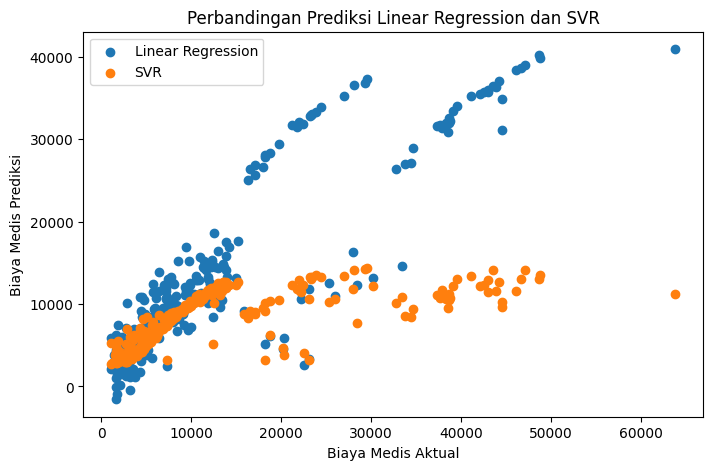

In [52]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_linear, label="Linear Regression")
plt.scatter(y_test, y_pred_svr, label="SVR")

plt.xlabel("Biaya Medis Aktual")
plt.ylabel("Biaya Medis Prediksi")
plt.title("Perbandingan Prediksi Linear Regression dan SVR")
plt.legend()

plt.show()

Berdasarkan hasil pengujian, model Multiple Linear Regression dan SVR digunakan untuk memprediksi biaya medis personal (charges). Dataset terdiri dari variabel usia, jenis kelamin, BMI, jumlah anak, status perokok, dan wilayah tempat tinggal. Sebelum proses training, data kategorikal diubah menjadi data numerik menggunakan One Hot Encoding dan dilakukan feature scaling pada variabel numerik. Setelah itu, kedua model dievaluasi menggunakan R-squared, MSE, dan MAE untuk melihat hasil prediksinya. R-squared digunakan untuk melihat seberapa baik model menjelaskan variasi biaya medis, sedangkan MSE dan MAE digunakan untuk melihat besar kesalahan prediksi. Dari hasil evaluasi tersebut, performa Linear Regression dan SVR dapat dibandingkan berdasarkan nilai yang diperoleh, di mana nilai R-squared yang lebih tinggi serta MSE dan MAE yang lebih rendah menunjukkan hasil prediksi yang lebih baik.